In [3]:
from llava.model.builder import load_pretrained_model
from llava.mm_utils import get_model_name_from_path, process_images, tokenizer_image_token
from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN, DEFAULT_IM_START_TOKEN, DEFAULT_IM_END_TOKEN, IGNORE_INDEX
from llava.conversation import conv_templates, SeparatorStyle

from PIL import Image
import requests
import copy
import torch

import sys
import warnings

# Load model
pretrained = "lmms-lab/llava-onevision-qwen2-0.5b-ov"
model_name = "llava_qwen"
device = "cuda"
device_map = "cuda:0"
llava_model_args = {
        "multimodal": True,
    }
overwrite_config = {}
overwrite_config["image_aspect_ratio"] = "pad"
llava_model_args["overwrite_config"] = overwrite_config
tokenizer, model, image_processor, max_length = load_pretrained_model(pretrained, None, model_name, device_map=device_map, **llava_model_args)

model.eval()
model.to(device_map)

# Load two images
url1 = "https://farm4.staticflickr.com/3033/2525881374_8fd592db02_z.jpg"
url2 = "https://farm9.staticflickr.com/8505/8368190901_db99698b2f_z.jpg"
url3 = "http://farm3.staticflickr.com/2776/4097335359_f1bca880ac_z.jpg"

image1 = Image.open(requests.get(url1, stream=True).raw)
image2 = Image.open(requests.get(url2, stream=True).raw)
image3 = Image.open(requests.get(url3, stream=True).raw)

images = [image1, image2, image3]
image_tensors = process_images(images, image_processor, model.config)
image_tensors = [_image.to(dtype=torch.float16, device=device) for _image in image_tensors]

# Prepare interleaved text-image input
conv_template = "qwen_1_5"
question = f"{DEFAULT_IMAGE_TOKEN} This is the first image. Can you describe what you see?\n\nNow, let's look at another image: {DEFAULT_IMAGE_TOKEN}\nWhat's the difference between these two images. Finally, look at this image : {DEFAULT_IMAGE_TOKEN}. Can you make a nonfiction story about these images?"

conv = copy.deepcopy(conv_templates[conv_template])
conv.append_message(conv.roles[0], question)
conv.append_message(conv.roles[1], None)
prompt_question = conv.get_prompt()

input_ids = tokenizer_image_token(prompt_question, tokenizer, IMAGE_TOKEN_INDEX, return_tensors="pt").unsqueeze(0).to(device_map)
image_sizes = [image.size for image in images]

Loaded LLaVA model: lmms-lab/llava-onevision-qwen2-0.5b-ov


You are using a model of type llava to instantiate a model of type llava_qwen. This is not supported for all configurations of models and can yield errors.


Overwriting config with {'image_aspect_ratio': 'pad'}
Loading vision tower: google/siglip-so400m-patch14-384
Model Class: LlavaQwenForCausalLM


In [5]:
# Generate response
cont = model.generate(
    input_ids,
    images=image_tensors,
    image_sizes=image_sizes,
    do_sample=False,
    temperature=0,
    max_new_tokens=4096,
)
text_outputs = tokenizer.batch_decode(cont, skip_special_tokens=True)
print(text_outputs[0])

/home/jjh_test/anaconda3/envs/torch2/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/jjh_test/anaconda3/envs/torch2/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/jjh_test/anaconda3/envs/torch2/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:589: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(
The attention mask is not

Once upon a time, in a small village nestled between rolling hills and dense forests, there lived a shepherd named John. He was known for his gentle heart and love of nature. One day, as he was tending to his flock of sheep, he noticed something peculiar - the sheep were not following him. They had wandered off from their designated path, heading towards an unknown destination.

John knew that if they continued on their own, they might get lost or even face danger. So, he decided to take matters into his own hands. With a determined look in his eyes, he mounted a sturdy tractor and set out to guide the sheep back home.

As they traveled down the muddy road, John used his experience to keep the sheep together. The journey was long and arduous, but John persevered, knowing that every step counted. Finally, after what felt like hours, they reached the end of the road where John's tractor came to a halt.

The sheep gathered around John, thanking him profusely for rescuing them. John smiled

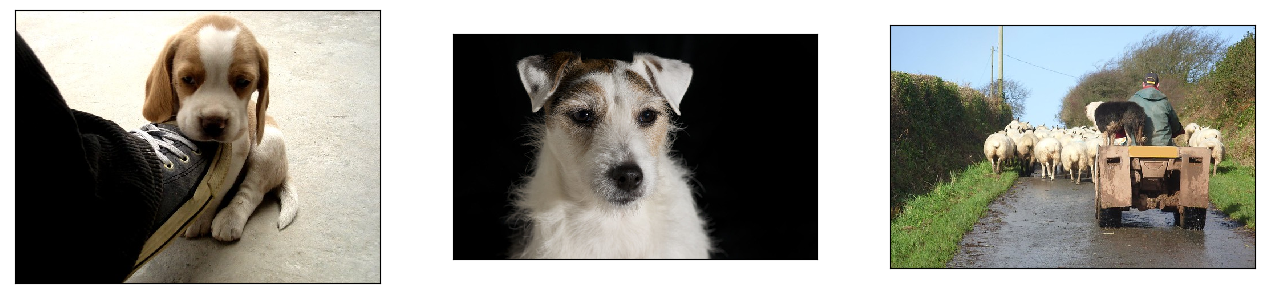

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

def plot_images(images):
    images_shown = 0
    plt.figure(figsize=(16, 9))
    
    for image in images:
        if isinstance(image, Image.Image):
            plt.subplot(2, 3, images_shown + 1)
            plt.imshow(image)
            plt.xticks([])
            plt.yticks([])

            images_shown += 1
            if images_shown >= 6:
                break

    plt.show()

plot_images(images)